### <div style="background-color:teal; color:white; padding:10px;"> Data Loading & Multi-Hot Targets (ADL) </div>

Builds the class map, per-frame **multi-hot** targets (overlaps + background), windowing, and the **10% stratified** seed mask. Every section prints the **shape / dtype / range** of what it produced, and saves `<P>_data.npz` + `class_map.pkl` for next steps.

In [6]:
# ===== CONFIG (edit paths) =====
from pathlib import Path
ADL_ROOT = Path(r'D:/Datasets/Datasets/ADL')
RGB_DIR  = ADL_ROOT/'Frames'
FLOW_DIR = ADL_ROOT/'OpticalFlow'
ANNO_DIR = ADL_ROOT/'Label'
OUT_DIR  = Path('./artifacts'); OUT_DIR.mkdir(exist_ok=True)

PARTICIPANTS = ["P_09",'P_10', 'P_11', "P_12", "P_16", "P_17"]        # add all participants, e.g. ['P_01',...]
N            = 100             # frames per window (graph size); sweep later in NB03
STRIDE       = N               # non-overlapping windows
INCLUDE_BACKGROUND = False     # True -> dedicated background class at index 0
SEED_FRAC    = 0.10
MIN_PER_CLASS= 2
RANDOM_SEED  = 42
print(f'config OK | participants={PARTICIPANTS} N={N} seed_frac={SEED_FRAC}')

config OK | participants=['P_09', 'P_10', 'P_11', 'P_12', 'P_16', 'P_17'] N=100 seed_frac=0.1


In [7]:
import numpy as np, pandas as pd
rng = np.random.default_rng(RANDOM_SEED)
def rgb_dir(p):  return RGB_DIR /p/f'Original_{p}'
def flow_dir(p): return FLOW_DIR/p/'viz'
def anno(p):     return ANNO_DIR/f'{p}_labeled.csv'
def ck(name,a):  print(f'  [check] {name}: shape={getattr(a,"shape",None)} dtype={getattr(a,"dtype",type(a).__name__)}'
                       f' min={np.min(a):.3f} max={np.max(a):.3f}' if hasattr(a,'shape') and a.size else f'  [check] {name}: {a}')

### <div style="background-color:teal; color:white; padding:10px;">  1. Global class map (non-contiguous ActionLabel -> contiguous index) </div>

In [8]:
def build_class_map(participants):
    rows=[pd.read_csv(anno(p))[['ActionLabel','ActionName']] for p in participants]
    alla=pd.concat(rows).drop_duplicates('ActionLabel').sort_values('ActionLabel')
    id2name=dict(zip(alla.ActionLabel,alla.ActionName)); ids=sorted(id2name)
    off=1 if INCLUDE_BACKGROUND else 0
    labelid2cls={l:i+off for i,l in enumerate(ids)}
    names={0:'background'} if INCLUDE_BACKGROUND else {}
    for l,ci in labelid2cls.items(): names[ci]=id2name[l]
    return dict(labelid2cls=labelid2cls,names=names,C=len(ids)+off)
CMAP=build_class_map(PARTICIPANTS)
print('num classes C =',CMAP['C'])
print('classes:',CMAP['names'])

num classes C = 28
classes: {0: 'Unknown', 1: 'combing hair', 2: 'make up', 3: 'brushing teeth', 4: 'washing hands/face', 5: 'drying hands/face', 6: 'adjusting thermostat', 7: 'laundry', 8: 'washing dishes', 9: 'making tea', 10: 'making coffee', 11: 'drinking water/bottle', 12: 'drinking water/tap', 13: 'making hot food', 14: 'making cold food/snack', 15: 'eating food/snack', 16: 'mopping in kitchen', 17: 'vacuuming', 18: 'taking pills', 19: 'watching tv', 20: 'using computer', 21: 'using cell', 22: 'cleaning house', 23: 'reading book', 24: 'using_mouth_wash', 25: 'writing', 26: 'putting on shoes/sucks', 27: 'drinking coffee/tea'}


### <div style="background-color:teal; color:white; padding:10px;">  2. Per-frame multi-hot targets (inclusive ranges; overlaps OR-accumulate) </div>

In [9]:
def num_frames(p): return len(sorted(rgb_dir(p).glob('frame_*.jpg')))
def build_multihot(p,nf,cmap):
    df=pd.read_csv(anno(p)); Y=np.zeros((nf,cmap['C']),np.float32)
    for _,r in df.iterrows():
        ci=cmap['labelid2cls'][int(r.ActionLabel)]
        s,e=int(r.StartFrame),min(int(r.EndFrame),nf-1); Y[s:e+1,ci]=1.0
    if INCLUDE_BACKGROUND: Y[Y[:,1:].sum(1)==0,0]=1.0
    return Y
TARGETS={}
for p in PARTICIPANTS:
    if not rgb_dir(p).exists(): raise FileNotFoundError(f'RGB frames missing: {rgb_dir(p)}')
    nf=num_frames(p); TARGETS[p]=build_multihot(p,nf,CMAP)
    Y=TARGETS[p]
    print(f'{p}: frames={nf}')
    ck('targets Y',Y)
    print(f'  labeled frames={int((Y.sum(1)>0).sum())} | frames with >=2 labels={int((Y.sum(1)>=2).sum())}')

P_09: frames=38631
  [check] targets Y: shape=(38631, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=34598 | frames with >=2 labels=1594
P_10: frames=28674
  [check] targets Y: shape=(28674, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=22592 | frames with >=2 labels=2162
P_11: frames=14775
  [check] targets Y: shape=(14775, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=13209 | frames with >=2 labels=571
P_12: frames=25317
  [check] targets Y: shape=(25317, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=23950 | frames with >=2 labels=2941
P_16: frames=25197
  [check] targets Y: shape=(25197, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=21400 | frames with >=2 labels=3
P_17: frames=26547
  [check] targets Y: shape=(26547, 28) dtype=float32 min=0.000 max=1.000
  labeled frames=18763 | frames with >=2 labels=216


### <div style="background-color:teal; color:white; padding:10px;">  3. Sanity check on the real annotation (P_11 overlap) </div>

In [16]:
for p, Y in TARGETS.items():
    multi = np.where(Y.sum(1) >= 2)[0]      # frames carrying >=2 concurrent actions
    n_multi = len(multi)
    print(f'{p}: {n_multi} frames with >=2 labels '
          f'({100*n_multi/Y.shape[0]:.1f}% of {Y.shape[0]} frames)')
    if n_multi:
        f = int(multi[len(multi)//2])       # a representative overlap frame
        active = [CMAP['names'][ci] for ci in np.where(Y[f] > 0)[0]]
        print(f'   e.g. frame {f}: {active}')
    else:
        print('   no overlapping segments in this participant (single-action only)')

P_09: 1594 frames with >=2 labels (4.1% of 38631 frames)
   e.g. frame 16426: ['reading book', 'writing']
P_10: 2162 frames with >=2 labels (7.5% of 28674 frames)
   e.g. frame 21750: ['watching tv', 'using computer']
P_11: 571 frames with >=2 labels (3.9% of 14775 frames)
   e.g. frame 11295: ['using computer', 'drinking coffee/tea']
P_12: 2941 frames with >=2 labels (11.6% of 25317 frames)
   e.g. frame 23070: ['eating food/snack', 'watching tv', 'drinking coffee/tea']
P_16: 3 frames with >=2 labels (0.0% of 25197 frames)
   e.g. frame 13530: ['making hot food', 'eating food/snack']
P_17: 216 frames with >=2 labels (0.8% of 26547 frames)
   e.g. frame 12407: ['washing dishes', 'making tea']


### <div style="background-color:teal; color:white; padding:10px;">  4. Windowing into N-frame graph clips </div>

In [11]:
def make_windows(nf,N,stride): return [list(range(s,s+N)) for s in range(0,nf-N+1,stride)]
WINDOWS={p:make_windows(TARGETS[p].shape[0],N,STRIDE) for p in PARTICIPANTS}
for p in PARTICIPANTS:
    print(f'{p}: {len(WINDOWS[p])} windows of size {N} | first={WINDOWS[p][0][:3]}...{WINDOWS[p][0][-1]}')

P_09: 386 windows of size 100 | first=[0, 1, 2]...99
P_10: 286 windows of size 100 | first=[0, 1, 2]...99
P_11: 147 windows of size 100 | first=[0, 1, 2]...99
P_12: 253 windows of size 100 | first=[0, 1, 2]...99
P_16: 251 windows of size 100 | first=[0, 1, 2]...99
P_17: 265 windows of size 100 | first=[0, 1, 2]...99


### <div style="background-color:teal; color:white; padding:10px;">  5. Stratified 10% seeds (>= MIN_PER_CLASS per class, rest random) </div>

In [12]:
def stratified_seeds(Y,frac,m,rng):
    n,C=Y.shape; labeled=np.where(Y.sum(1)>0)[0]; budget=max(int(round(frac*len(labeled))),1)
    chosen=set()
    for c in range(C):
        pool=np.where(Y[:,c]>0)[0]
        if len(pool): chosen.update(rng.choice(pool,min(m,len(pool)),replace=False).tolist())
    rem=[i for i in labeled if i not in chosen]
    if len(chosen)<budget and rem:
        chosen.update(rng.choice(rem,min(budget-len(chosen),len(rem)),replace=False).tolist())
    mask=np.zeros(n,bool); mask[list(chosen)]=True; return mask
SEEDS={p:stratified_seeds(TARGETS[p],SEED_FRAC,MIN_PER_CLASS,rng) for p in PARTICIPANTS}
for p in PARTICIPANTS:
    Y,sd=TARGETS[p],SEEDS[p]
    print(f'{p}: seeds={int(sd.sum())}/{int((Y.sum(1)>0).sum())} labeled')
    per_class=Y[sd].sum(0).astype(int)
    print('  seeds per class:',{CMAP["names"][ci]:int(per_class[ci]) for ci in range(CMAP['C'])})

P_09: seeds=3460/34598 labeled
  seeds per class: {'Unknown': 0, 'combing hair': 71, 'make up': 0, 'brushing teeth': 241, 'washing hands/face': 204, 'drying hands/face': 50, 'adjusting thermostat': 61, 'laundry': 293, 'washing dishes': 14, 'making tea': 239, 'making coffee': 0, 'drinking water/bottle': 146, 'drinking water/tap': 0, 'making hot food': 0, 'making cold food/snack': 0, 'eating food/snack': 315, 'mopping in kitchen': 0, 'vacuuming': 199, 'taking pills': 119, 'watching tv': 288, 'using computer': 323, 'using cell': 254, 'cleaning house': 0, 'reading book': 565, 'using_mouth_wash': 0, 'writing': 227, 'putting on shoes/sucks': 0, 'drinking coffee/tea': 21}
P_10: seeds=2259/22592 labeled
  seeds per class: {'Unknown': 0, 'combing hair': 0, 'make up': 0, 'brushing teeth': 498, 'washing hands/face': 0, 'drying hands/face': 36, 'adjusting thermostat': 0, 'laundry': 0, 'washing dishes': 57, 'making tea': 256, 'making coffee': 0, 'drinking water/bottle': 0, 'drinking water/tap': 0, 

### <div style="background-color:teal; color:white; padding:10px;">  Visual — seeds per class (catch zero-seed classes early) </div>

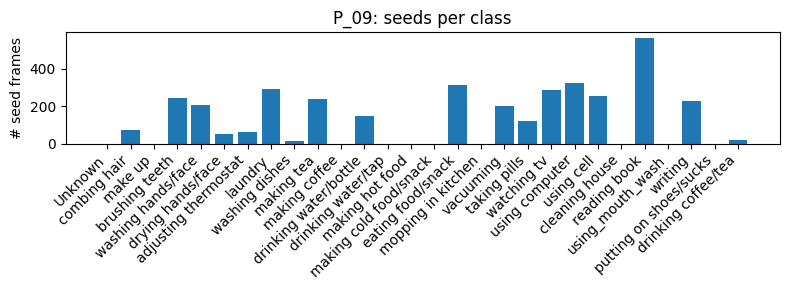

In [13]:
try:
    import matplotlib.pyplot as plt
    p=PARTICIPANTS[0]; Y,sd=TARGETS[p],SEEDS[p]; per_class=Y[sd].sum(0)
    fig,ax=plt.subplots(figsize=(8,3))
    ax.bar(range(CMAP['C']),per_class)
    ax.set_xticks(range(CMAP['C'])); ax.set_xticklabels([CMAP['names'][i] for i in range(CMAP['C'])],rotation=45,ha='right')
    ax.set_ylabel('# seed frames'); ax.set_title(f'{p}: seeds per class'); plt.tight_layout(); plt.show()
except Exception as e:
    print('plot skipped:',e)

### <div style="background-color:teal; color:white; padding:10px;">  Class coverage (per participant + pooled) — does pooling help the rare classes? </div>

In [14]:
# How many seed frames each class gets, per participant and POOLED across all participants.
# A class with 0 pooled seeds can never be recovered; pooling should lift the rare ones.
names=CMAP['names']
pooled_seed=np.zeros(CMAP['C']); pooled_lab=np.zeros(CMAP['C'])
per_p_seed={p:TARGETS[p][SEEDS[p]].sum(0) for p in PARTICIPANTS}
per_p_lab ={p:(TARGETS[p]>0).sum(0) for p in PARTICIPANTS}
print(f'{"class":<24}'+''.join(f'{p+" seed":>12}' for p in PARTICIPANTS)+f'{"POOLED seed":>14}{"POOLED lab":>12}')
for ci in range(CMAP['C']):
    row=f'{names[ci][:23]:<24}'
    for p in PARTICIPANTS:
        row+=f'{int(per_p_seed[p][ci]):>12}'
        pooled_seed[ci]+=per_p_seed[p][ci]; pooled_lab[ci]+=per_p_lab[p][ci]
    row+=f'{int(pooled_seed[ci]):>14}{int(pooled_lab[ci]):>12}'
    print(row)
zero=[names[ci] for ci in range(CMAP['C']) if pooled_seed[ci]==0]
print(f'\nclasses with ZERO pooled seeds (unrecoverable): {zero if zero else "none"}')
print(f'classes present: {int((pooled_lab>0).sum())}/{CMAP["C"]}')

class                      P_09 seed   P_10 seed   P_11 seed   P_12 seed   P_16 seed   P_17 seed   POOLED seed  POOLED lab
Unknown                            0           0           0           0           0         146           146        1411
combing hair                      71           0           0           0          52           0           123        1312
make up                            0           0           0           0           0          48            48         391
brushing teeth                   241         498           0         142         216          76          1173       11795
washing hands/face               204           0          46          44          79          77           450        4717
drying hands/face                 50          36          30          66          70          39           291        2861
adjusting thermostat              61           0           0           0          25          13            99        1023
laundry         

### <div style="background-color:teal; color:white; padding:10px;">  6. Save artifacts </div>

In [15]:
import pickle
pickle.dump(CMAP,open(OUT_DIR/'class_map.pkl','wb'))
for p in PARTICIPANTS:
    np.savez_compressed(OUT_DIR/f'{p}_data.npz',targets=TARGETS[p],seeds=SEEDS[p],
                        windows=np.array(WINDOWS[p],dtype=object))
    print(f'saved {p}_data.npz -> targets{TARGETS[p].shape}, seeds({int(SEEDS[p].sum())}), windows({len(WINDOWS[p])})')
print('done ->',OUT_DIR.resolve())

saved P_09_data.npz -> targets(38631, 28), seeds(3460), windows(386)
saved P_10_data.npz -> targets(28674, 28), seeds(2259), windows(286)
saved P_11_data.npz -> targets(14775, 28), seeds(1321), windows(147)
saved P_12_data.npz -> targets(25317, 28), seeds(2395), windows(253)
saved P_16_data.npz -> targets(25197, 28), seeds(2140), windows(251)
saved P_17_data.npz -> targets(26547, 28), seeds(1876), windows(265)
done -> C:\Users\PAWANESH\ICVGIP\artifacts
